In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, RocCurveDisplay
)

# Load data
df = pd.read_csv('phishing_email.csv')

In [ ]:
# check NaN
df.isna().sum()

,0
text_combined,0
label,0


In [ ]:
# check the data type
df.dtypes

,0
text_combined,object
label,int64


In [ ]:
# check distribution
df['label'].value_counts()

,count
label,
1,42891
0,39595


Based on the distribution, this dataset is balanced

In [ ]:
# train-test-split
X = df['text_combined']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
# check X_train distribution
y_train.value_counts()

,count
label,
1,34312
0,31676


In [ ]:
# check X_test distribution
y_test.value_counts()

,count
label,
1,8579
0,7919


In [ ]:
# Text vectorization using Bag-of-Words
vectorizer_BoW = CountVectorizer(stop_words='english', max_df=0.7)
# Text vectorization using TF-IDF
vectorizer_TFIDF = TfidfVectorizer(stop_words='english', max_df=0.7)

In [ ]:
# making k folders in X_train and y_train
from sklearn.model_selection import StratifiedKFold

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
conf_matrix_list = []
ROU_list = []

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
for i, (train_idx, validate_idx) in enumerate(skf.split(X_train, y_train)):
    X_train_fold, X_validate_fold = X_train.iloc[train_idx], X_train.iloc[validate_idx]
    y_train_fold, y_validate_fold = y_train.iloc[train_idx], y_train.iloc[validate_idx]

    X_train_fold_BoW = vectorizer_BoW.fit_transform(X_train_fold)
    X_validate_fold_BoW = vectorizer_BoW.transform(X_validate_fold)

    # Train model
    model = MultinomialNB()
    model.fit(X_train_fold_BoW, y_train_fold)

    # Predict
    y_pred_fold = model.predict(X_validate_fold_BoW)
    y_proba_fold = model.predict_proba(X_validate_fold_BoW)[:, 1]

    # Evaluation
    accuracy_list.append(accuracy_score(y_validate_fold, y_pred_fold))
    precision_list.append(precision_score(y_validate_fold, y_pred_fold))
    recall_list.append(recall_score(y_validate_fold, y_pred_fold))
    f1_list.append(f1_score(y_validate_fold, y_pred_fold))
    conf_matrix_list.append(confusion_matrix(y_validate_fold, y_pred_fold))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_validate_fold, y_proba_fold)
    roc_auc = auc(fpr, tpr)
    ROU_list.append(roc_auc)

In [ ]:
# print avg of 5-Fold Cross-Validation Results
print(f"Avg Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Avg Precision: {np.mean(precision_list):.4f}")
print(f"Avg Recall: {np.mean(recall_list):.4f}")
print(f"Avg F1-score: {np.mean(f1_list):.4f}")
print(f"Avg ROC AUC: {np.mean(ROU_list):.4f}")
for conf_matrix in conf_matrix_list:
    print("Confusion Matrix:")
    print(conf_matrix)
    print("\n")

Avg Accuracy: 0.9785
Avg Precision: 0.9914
Avg Recall: 0.9671
Avg F1-score: 0.9791
Avg ROC AUC: 0.9960
Confusion Matrix:
[[6266   70]
 [ 217 6645]]


Confusion Matrix:
[[6276   59]
 [ 231 6632]]


Confusion Matrix:
[[6290   45]
 [ 228 6635]]


Confusion Matrix:
[[6275   60]
 [ 209 6653]]


Confusion Matrix:
[[6280   55]
 [ 243 6619]]




Accuracy: 0.9770
Precision: 0.9902
Recall: 0.9653
F1-score: 0.9776
Confusion Matrix:
[[7837   82]
 [ 298 8281]]
ROC AUC: 0.9958


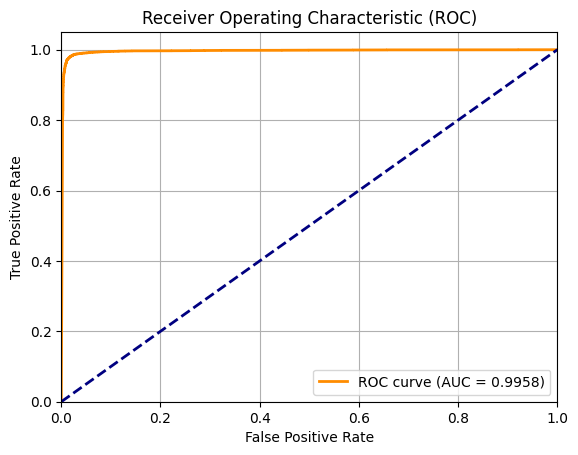

In [ ]:
import matplotlib.pyplot as plt
# predict on test data
X_test_BoW = vectorizer_BoW.transform(X_test)
y_pred = model.predict(X_test_BoW)
y_proba = model.predict_proba(X_test_BoW)[:, 1]

# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

# plot ROC AUC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

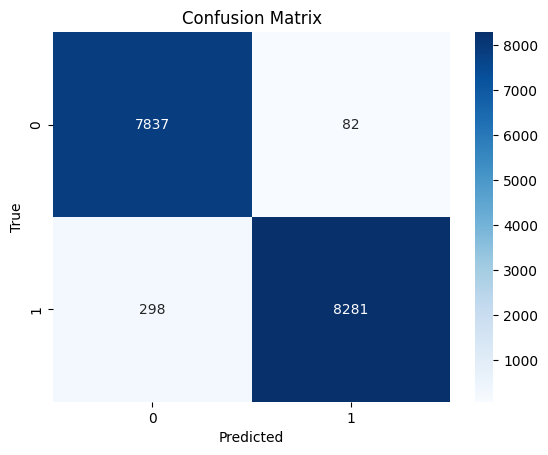

In [ ]:
# Plot heatmap of confusion matrix
import seaborn as sns
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Fold 1:
Accuracy: 0.9764
Precision: 0.9884
Recall: 0.9660
F1-score: 0.9771
Confusion Matrix:
[[6258   78]
 [ 233 6629]]


ROC AUC: 0.9982


Fold 2:
Accuracy: 0.9766
Precision: 0.9895
Recall: 0.9652
F1-score: 0.9772
Confusion Matrix:
[[6265   70]
 [ 239 6624]]


ROC AUC: 0.9983


Fold 3:
Accuracy: 0.9773
Precision: 0.9901
Recall: 0.9660
F1-score: 0.9779
Confusion Matrix:
[[6269   66]
 [ 233 6630]]


ROC AUC: 0.9980


Fold 4:
Accuracy: 0.9776
Precision: 0.9894
Recall: 0.9674
F1-score: 0.9783
Confusion Matrix:
[[6264   71]
 [ 224 6638]]


ROC AUC: 0.9980


Fold 5:
Accuracy: 0.9753
Precision: 0.9891
Recall: 0.9631
F1-score: 0.9759
Confusion Matrix:
[[6262   73]
 [ 253 6609]]


ROC AUC: 0.9977


Accuracy: 0.9762
Precision: 0.9890
Recall: 0.9649
F1-score: 0.9768
Confusion Matrix:
[[7827   92]
 [ 301 8278]]
ROC AUC: 0.9978


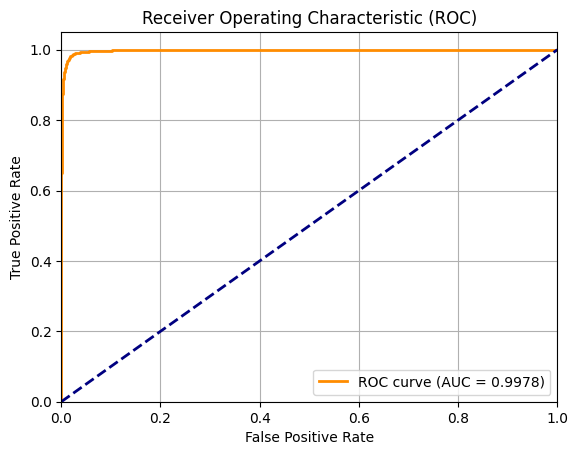

In [ ]:
# Try TF-IDF
# making k folders in X_train and y_train
for i, (train_idx, validate_idx) in enumerate(skf.split(X_train, y_train)):
    X_train_fold, X_validate_fold = X_train.iloc[train_idx], X_train.iloc[validate_idx]
    y_train_fold, y_validate_fold = y_train.iloc[train_idx], y_train.iloc[validate_idx]

    X_train_fold_TFIDF = vectorizer_TFIDF.fit_transform(X_train_fold)
    X_validate_fold_TFIDF = vectorizer_TFIDF.transform(X_validate_fold)

    # Train model
    model = MultinomialNB()
    model.fit(X_train_fold_TFIDF, y_train_fold)

    # Predict
    y_pred_fold = model.predict(X_validate_fold_TFIDF)
    y_proba_fold = model.predict_proba(X_validate_fold_TFIDF)[:, 1]

    # Evaluation
    accuracy = accuracy_score(y_validate_fold, y_pred_fold)
    precision = precision_score(y_validate_fold, y_pred_fold)
    recall = recall_score(y_validate_fold, y_pred_fold)
    f1 = f1_score(y_validate_fold, y_pred_fold)
    conf_matrix = confusion_matrix(y_validate_fold, y_pred_fold)

    print(f"Fold {i+1}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    print("\n")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_validate_fold, y_proba_fold)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\n")

# predict on test data
X_test_TFIDF = vectorizer_TFIDF.transform(X_test)
y_pred = model.predict(X_test_TFIDF)
y_proba = model.predict_proba(X_test_TFIDF)[:, 1]

# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

# plot ROC AUC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()